# Car Price Prediction – Regression Project

Group Members: 
Aashish Shrestha, Pramis Adhikari, Rahul Harijan, Adeyemi Adekunle  
Module: AI and Machine Learning  

Dataset: Car Price Dataset  
Task: Predict used car **selling_price** from vehicle and seller attributes.


### Setup

In [1]:
# Regression.ipynb

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Show plots nicely inside the notebook
%matplotlib inline
sns.set(style="whitegrid")


In [2]:
# Data Loading and Initial Overview

df = pd.read_csv("CAR_Price_Dataset.csv")
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000.0,50000.0,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000.0,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000.0,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000.0,141000.0,Diesel,Individual,Manual,Second Owner


### 1. Basic info

In [3]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nDescribe numeric:")
display(df.describe())
   
print("\nMissing values per column:")
print(df.isna().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())


Shape: (4340, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   object 
 1   year           4340 non-null   int64  
 2   selling_price  4333 non-null   float64
 3   km_driven      4335 non-null   float64
 4   fuel           4340 non-null   object 
 5   seller_type    4334 non-null   object 
 6   transmission   4340 non-null   object 
 7   owner          4340 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 271.4+ KB

Describe numeric:


,year,selling_price,km_driven
count,4340.000000,4.333000e+03,4335.000000
mean,2013.090783,5.041582e+05,66230.120877
std,4.215344,5.789089e+05,46618.590991
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.100000e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000



Missing values per column:
name             0
year             0
selling_price    7
km_driven        5
fuel             0
seller_type      6
transmission     0
owner            0
dtype: int64

Number of duplicate rows: 753


Data Quality Check:
1. Missing Values: selling_price has 7 missing values, while km_driven has 5 missing values and seller_type has 6 missing value.
2. Duplicate Rows: There are 753 duplicate rows in the dataset.
3. Data Types: The data types of the features are as follows:
   - selling_price: float64
   - km_driven: float64
   - seller_type: object
   - transmission: object
   - owner: object
   - year: int64


### 2. Exploratory Data Analysis (EDA)

In [4]:
# Drop Duplicate Rows and Handle Missing Values

# Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Handle missing km_driven values(Numerical) using median 
df_cleaned['km_driven'].fillna(df_cleaned['km_driven'].median(), inplace=True)

# Handle missing values in seller_type using mode
df_cleaned['seller_type'].fillna(df_cleaned['seller_type'].mode()[0], inplace=True)

# Handle missing values in selling_price by dropping rows
df_cleaned.dropna(subset=['selling_price'], inplace=True)

print("\nNumber of duplicate rows:", df_cleaned.isnull().sum())

print('shape of original data:', df.shape)
print("Shape of cleaned data:", df_cleaned.shape)



Number of duplicate rows: name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64
shape of original data: (4340, 8)
Shape of cleaned data: (3580, 8)


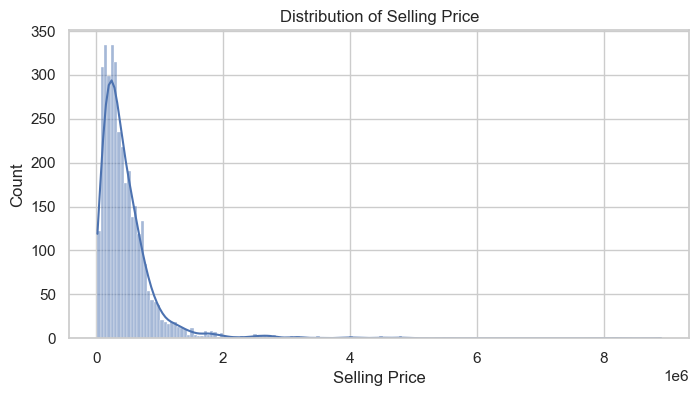

In [5]:
# 1. Target distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned['selling_price'], kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.show()


Selling Price exhibits a stronge right-skewed distribution, The vast majority of cars cluster at the lower end of the price spectrum (below 1,000,000), while a long tail extends towards the extremely high-priced cars. 
This non-normal distribution can negatively affects the performance of many machine learning models, as they often assume a normal or near-normal distribution of the target variable. To address this issue, skewness might necessitate a log transformation of the target variable to normalize the distribution.

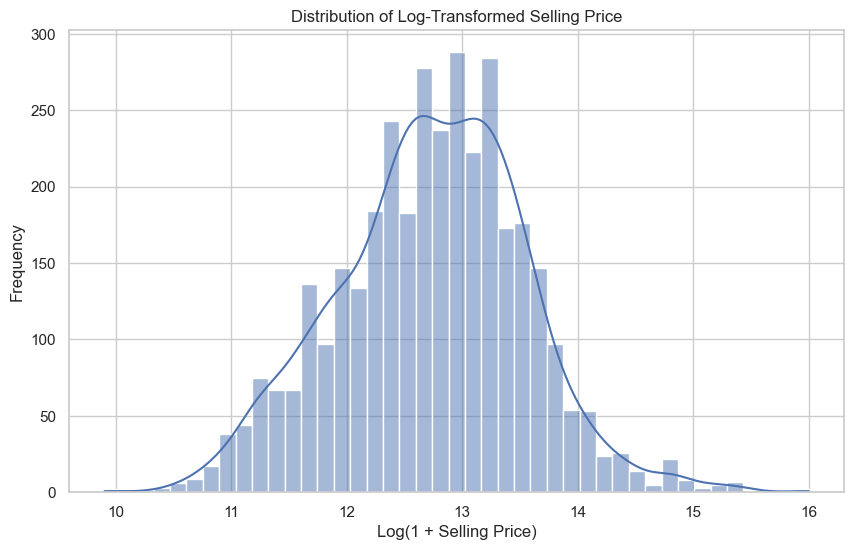

In [6]:
# 1.1 Target Variable Log Transformation

df_cleaned['selling_price_log'] = np.log1p(df_cleaned['selling_price'])
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['selling_price_log'], kde=True)
plt.title('Distribution of Log-Transformed Selling Price')
plt.xlabel('Log(1 + Selling Price)')
plt.ylabel('Frequency')
plt.show()


After applying a log(1 + selling_price) transformation, the distribution of the target variable becomes much more symmetric and approximately bell-shaped, The long right tail is compressed, and the extremely high-priced cars no longer dominate the scale. This transformation reduces skewness, stabilises the variance across price levels, and better aligns the target variable with the assumptions of many regression algorithms.

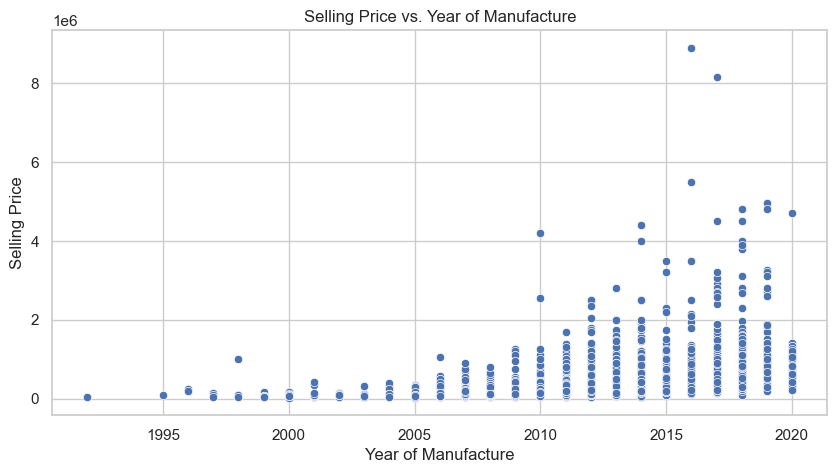

In [7]:
# 2. Relationship between 'year' and 'selling_price'
plt.figure(figsize=(10, 5))

sns.scatterplot(x='year', y='selling_price', data=df_cleaned)
plt.title('Selling Price vs. Year of Manufacture')
plt.xlabel('Year of Manufacture')
plt.ylabel('Selling Price')
plt.show()

 There is a clear positive trend: as the year of the car increases, the price also increases. This indicates a strong correlation between the year of the  manufacture of the car and its price. This is a clearest inidcator that older cars tend to have lower prices.

 Since the relationship is not perfectly linear, the data points are spread out aroun the newer, more expensive cars, we can convert year into a car_age feature, providing a measure of depreciation that might simplify the relationship for the model.

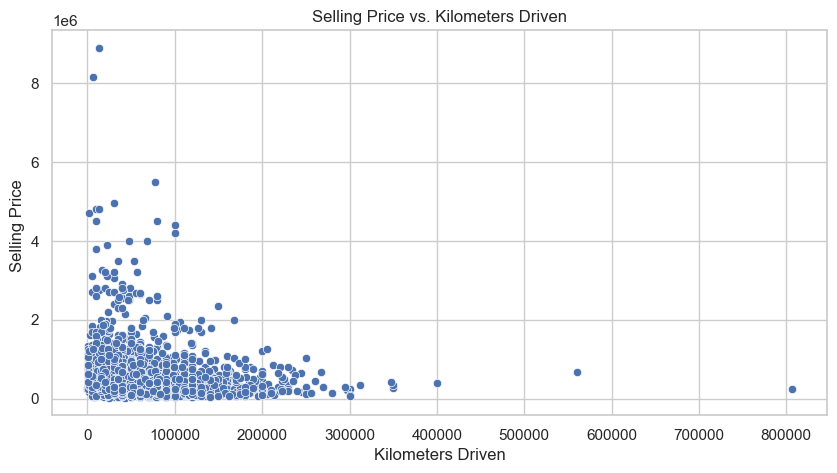

In [8]:
# 3. Relationship between kilometers driven and selling price
plt.figure(figsize=(10, 5))

sns.scatterplot(x='km_driven', y='selling_price', data=df_cleaned)
plt.title('Selling Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price ')
plt.show()

A weak correlation exists between the Km_driven and selling_price columns. Cars with lower mileage tend to have higher selling prices, and as mileage increases, the selling price decreases. However, there a dense cluster of low to medium priced cars across all mileage levels, diluting the correlation.

km_driven is an important factor, but likely less influential than age.  the scatter pattern(heteroscedasticity) indicate that the impact of mileage on price is not consistent across the data, it shows is more significant for expensive cars than the cheaper ones.

####  Feature Engineering: Creating car_age feature
The previous analysis revealed a strong positive correlation between year and selling price. To capture this relationship, we create a new feature called car_age, which represents the age of the car in years.

In [9]:
# Feature Engineering

CURRENT_YEAR = datetime.now().year

# Create 'car_age' column
df_cleaned['car_age'] = CURRENT_YEAR - df_cleaned['year']

# Drop the 'year' column (correctly)
df_cleaned.drop(columns=['year'], inplace=True, axis=1)

# Now you can print
print(df_cleaned[['car_age', 'selling_price', 'km_driven']].head())

   car_age  selling_price  km_driven
0       18        60000.0    70000.0
1       18       135000.0    50000.0
2       13       600000.0   100000.0
3        8       250000.0    46000.0
4       11       450000.0   141000.0


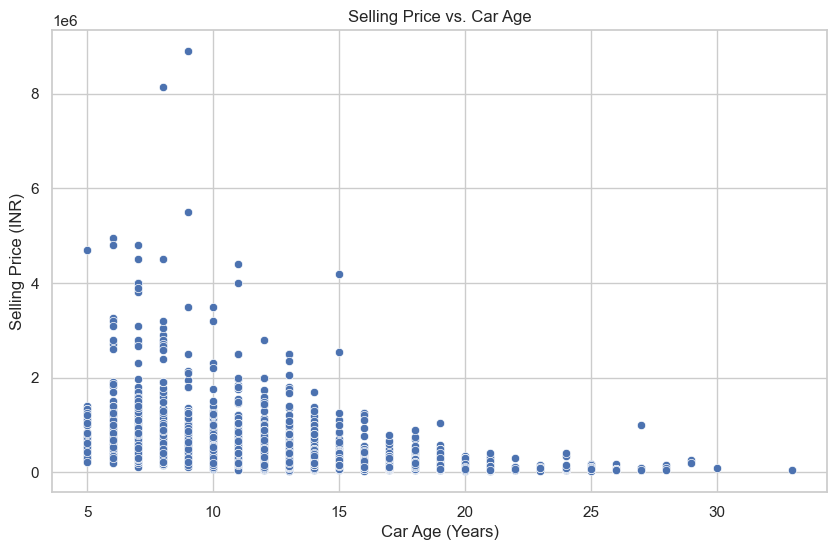

In [10]:
# 4. Let visualise the new relationship 'car_age' and 'selling_price'

plt.figure(figsize=(10, 6))
sns.scatterplot(x='car_age', y='selling_price', data=df_cleaned)
plt.title('Selling Price vs. Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (INR)')
plt.show()

The relationship is now clearly nagative and exponential. Newer cars(low car_age) show a steep decline in price, while older cars(high car_age) show a gradual decline in price.

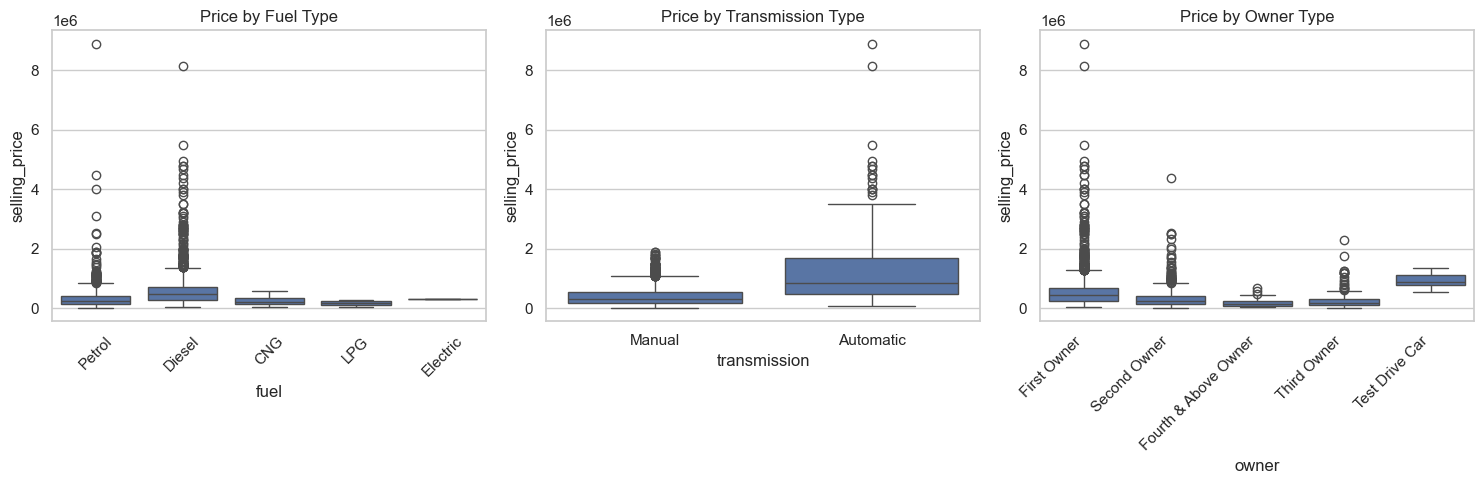

In [11]:
# Categorical Features vs Selling Price

categorical_features = ['fuel', 'transmission', 'owner']

plt.figure(figsize=(15, 5))

# Plot 5: Fuel vs. Price
plt.subplot(1, 3, 1)
sns.boxplot(x='fuel', y='selling_price', data=df_cleaned)
plt.title('Price by Fuel Type')
plt.xticks(rotation=45)

# Plot 6: Transmission vs. Price
plt.subplot(1, 3, 2)
sns.boxplot(x='transmission', y='selling_price', data=df_cleaned)
plt.title('Price by Transmission Type')

# Plot 7: Owner vs. Price
plt.subplot(1, 3, 3)
sns.boxplot(x='owner', y='selling_price', data=df_cleaned)
plt.title('Price by Owner Type')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Fuel Type: Diesel cars generally have the highest median selling price and the largest upper quartile (suggesting the most expensive cars overall), followed by Petrol, then CNG/LPG. This is a crucial feature indicating a clear market preference and value for Diesel variants.

Transmission Type: There is a significant difference in price based on transmission. Automatic cars command a much higher median price and display a much greater variance and upper price range compared to Manual cars, confirming the premium value of automatic transmission.

Owner Type: First Owner cars have the highest median price and the largest upper range, followed closely by Second Owner cars. Prices drop substantially and consistently as the number of previous owners increases, illustrating that the "newness" of ownership is a strong indicator of retained value.

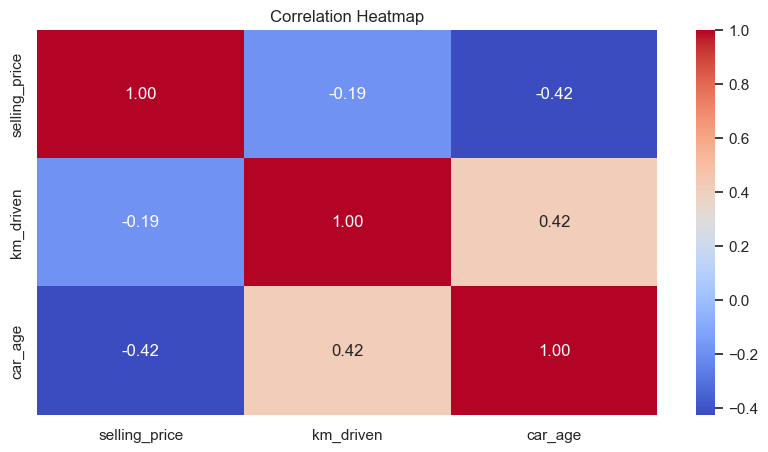

In [12]:
# Correlation heatmap (numeric + target) 
numeric_cols = ['selling_price', 'km_driven', 'car_age']

plt.figure(figsize=(10, 5))
corr = df_cleaned[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


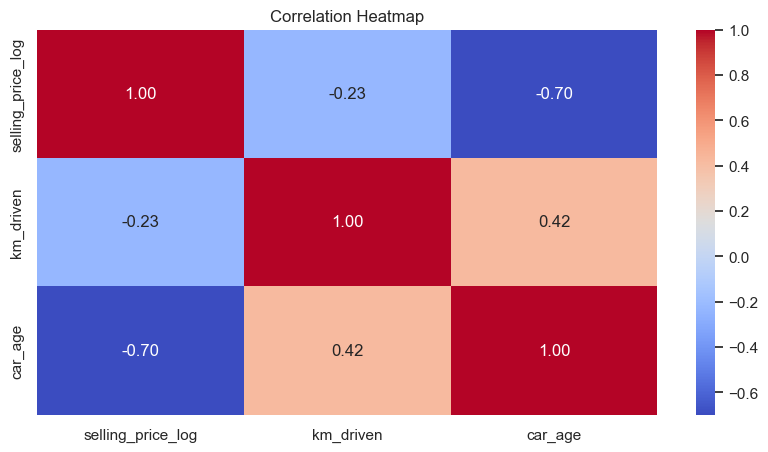

In [13]:
# Correlation heatmap (numeric + selling_price_log) 
numeric_cols = ['selling_price_log', 'km_driven', 'car_age']

plt.figure(figsize=(10, 5))
corr = df_cleaned[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The selling price variable is strongly right skewed, with a long tail of very expensive cars. We applied a log transformation to stabilize the variance and reveal an improve linear relationship with the predictors such car_age and km_driven.

The correlation heatmap using selling_price_log shows stronger linear associations, supporting its use as a transformed target/feature during modelling.


### 3. Model Development

In [14]:
# Spliting Data and Preprocessing Pipeline
feature_cols = ["km_driven", "car_age", "fuel", "seller_type", "transmission", "owner"]

X = df_cleaned[feature_cols]
y_log = df_cleaned['selling_price_log']

# Train-test split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=RANDOM_STATE)

# Preprocessing Pipeline
numeric_features = ["km_driven", "car_age"]
categorical_features = ["fuel", "seller_type", "transmission", "owner"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat",  OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

print(f"Features used for modeling: {feature_cols}")
print(f"Training set size: {len(X_train)} samples")



Features used for modeling: ['km_driven', 'car_age', 'fuel', 'seller_type', 'transmission', 'owner']
Training set size: 2864 samples


In [15]:
# Linear Regression

lr_pipeline = Pipeline(steps=[('preprocess', preprocessor), ('lr', LinearRegression())])
lr_pipeline.fit(X_train, y_train_log)
y_pred_lr = lr_pipeline.predict(X_test)


# Evaluate Linear Regression
# Metrics on Log Scale
lr_r2_log = r2_score(y_test_log, y_pred_lr)
lr_mse_log = mean_squared_error(y_test_log, y_pred_lr)
lr_rmse_log = np.sqrt(lr_mse_log)

# Metrics on Original Scale (Inverse Transform)
y_test_original = np.exp(y_test_log)
y_pred_lr_original = np.exp(y_pred_lr)

lr_r2 = r2_score(y_test_original, y_pred_lr_original)
lr_mse = mean_squared_error(y_test_original, y_pred_lr_original)
lr_rmse = np.sqrt(lr_mse)

print(f"Linear Regression R2 (Log Scale): {lr_r2_log:.4f}")
print(f"Linear Regression RMSE (Log Scale): {lr_rmse_log:.4f}")

print(f"Linear Regression R2 (Original Scale): {lr_r2:.4f}")
print(f"Linear Regression RMSE (Original Scale): {lr_rmse:.2f}")




Linear Regression R2 (Log Scale): 0.6735
Linear Regression RMSE (Log Scale): 0.4559
Linear Regression R2 (Original Scale): 0.4422
Linear Regression RMSE (Original Scale): 388841.84


In [16]:
# Linear Regression - K-fold Cross Validation

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2_lr = cross_val_score(lr_pipeline, X_train, y_train_log, cv=kfold, scoring='r2', n_jobs=-1)
cv_rmse_lr = cross_val_score(lr_pipeline, X_train, y_train_log, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)

print("\n--- Linear Regression: K-Fold Cross-Validation (5-Fold) ---")
print(f"Mean R-squared (Log Scale): {cv_r2_lr.mean():.4f} ")
print(f"Mean RMSE (Log Scale): {-cv_rmse_lr.mean():.4f} ")


--- Linear Regression: K-Fold Cross-Validation (5-Fold) ---
Mean R-squared (Log Scale): 0.6665 
Mean RMSE (Log Scale): 0.4732 


In [23]:
# Support Vector Regression

svr_pipeline = Pipeline([('preprocessor', preprocessor),('svr', SVR())])
svr_pipeline.fit(X_train, y_train_log)
y_pred_svr = svr_pipeline.predict(X_test)


# Evaluate on SVR Log Scale

svr_r2_log = r2_score(y_test_log, y_pred_svr)
svr_mse_log = mean_squared_error(y_test_log, y_pred_svr)
svr_rmse_log = np.sqrt(svr_mse_log)
print(f"SVR R2 Log: {svr_r2_log:.4f}")
print(f"SVR RMSE Log: {svr_rmse_log:.4f}")

# Metrics on SVR Original Scale
y_pred_svr_original = np.expm1(y_pred_svr)

svr_r2 = r2_score(y_test_original, y_pred_svr_original)
svr_mse = mean_squared_error(y_test_original, y_pred_svr_original)
svr_rmse = np.sqrt(svr_mse)

print(f"SVR R2: {svr_r2:.4f}")
print(f"SVR RMSE: {svr_rmse:.2f}")



SVR R2 Log: 0.7004
SVR RMSE Log: 0.4367
SVR R2: 0.5023
SVR RMSE: 367284.53


In [19]:
# SVM Regression- K-fold Cross Validation


cv_r2_svr = cross_val_score(svr_pipeline, X_train, y_train_log, cv=kfold, scoring='r2', n_jobs=-1)
cv_rmse_svr = cross_val_score(svr_pipeline, X_train, y_train_log, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)

print("\n--- SVR: K-Fold Cross-Validation (5-Fold) ---")
print(f"Mean R-squared (Log Scale): {cv_r2_svr.mean():.4f} ")
print(f"Mean RMSE (Log Scale): {-cv_rmse_svr.mean():.4f} ")


--- SVR: K-Fold Cross-Validation (5-Fold) ---
Mean R-squared (Log Scale): 0.6756 
Mean RMSE (Log Scale): 0.4667 


In [22]:
# Random Forest Regressor

rf_pipeline = Pipeline(steps=[('preprocess', preprocessor), ('rf', RandomForestRegressor(random_state=42))])
rf_pipeline.fit(X_train, y_train_log)
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate Random Forest Regressor

# Log scale
rf_r2_log = r2_score(y_test_log, y_pred_rf)
rf_mse_log = mean_squared_error(y_test_log, y_pred_rf)
rf_rmse_log = np.sqrt(rf_mse_log)
print(f"Random Forest Regressor R2 Score (Log): {rf_r2_log:.4f}")
print(f"Random Forest Regressor RMSE (Log): {rf_rmse_log:.4f}")

# Original scale
y_pred_rf_original = np.expm1(y_pred_rf)
rf_r2 = r2_score(y_test_original, y_pred_rf_original)
rf_mse = mean_squared_error(y_test_original, y_pred_rf_original)
rf_rmse = np.sqrt(rf_mse)
print(f"Random Forest Regressor R2 Score (Original): {rf_r2:.4f}")
print(f"Random Forest Regressor RMSE (Original): {rf_rmse:.2f}")

Random Forest Regressor R2 Score (Log): 0.6008
Random Forest Regressor RMSE (Log): 0.5042
Random Forest Regressor R2 Score (Original): 0.5176
Random Forest Regressor RMSE (Original): 361617.88
